In [1]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform
from scipy.linalg import eigh
from scipy.stats import rankdata

for _name, _type in {"float": float, "int": int, "bool": bool, "object": object}.items():
    if not hasattr(np, _name):
        setattr(np, _name, _type)
from openpyxl import load_workbook

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
sns.set_theme(style="white", context="notebook")
plt.rcParams["svg.fonttype"] = "none"

SMORF_FILE = "../pre-calculated_data/smorf_mapped_contig.tsv"
META_FILE = "../pre-calculated_data/supp1_sample_metadata.xlsx"


c:\Users\admin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
<ipython-input-1-b3c38c78d012>:10: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _name):
<ipython-input-1-b3c38c78d012>:10: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _name):


In [2]:
def read_first_excel_sheet(path):
    workbook = load_workbook(path, read_only=True, data_only=True)
    sheet = workbook[workbook.sheetnames[0]]
    rows = list(sheet.iter_rows(values_only=True))
    return pd.DataFrame(rows[1:], columns=rows[0])

def month_label(value):
    text = str(value).strip()
    for fmt in ("%m-%d-%Y", "%m-%Y", "%Y-%m-%d", "%Y-%m"):
        try:
            return pd.to_datetime(text, format=fmt).strftime("%Y-%m")
        except ValueError:
            pass
    return pd.to_datetime(text).strftime("%Y-%m")

meta = read_first_excel_sheet(META_FILE)
required_meta = {"Sample_id", "City", "Location", "Date"}
meta["Sample_id"] = meta["Sample_id"].astype(str).str.strip()
meta["Time"] = meta["Date"].map(month_label)

sample_order = meta["Sample_id"].tolist()
sample_to_index = {sample: index for index, sample in enumerate(sample_order)}


In [3]:
row_arrays = []
column_arrays = []
observed_samples = set()
unparsed_contigs = 0
contig_entries = 0
total_clusters = 0
chunk_size = 250_000

reader = pd.read_csv(
    SMORF_FILE, sep="\t", header=None, usecols=[0, 3],
    dtype=str, chunksize=chunk_size,
)
for chunk_number, chunk in enumerate(reader, start=1):
    contigs = chunk[3].str.split(",").explode().str.strip()
    samples = contigs.str.extract(r"^([^_]+)_contig_", expand=False)
    unparsed_contigs += int(samples.isna().sum())
    contig_entries += len(samples)
    observed_samples.update(samples.dropna().unique())

    sample_codes = samples.map(sample_to_index)
    unknown = sorted(samples.loc[sample_codes.isna() & samples.notna()].unique())

    valid = sample_codes.notna()
    row_arrays.append(sample_codes.loc[valid].to_numpy(dtype=np.int16))
    column_arrays.append(contigs.index.to_numpy(dtype=np.int32)[valid.to_numpy()])
    total_clusters += len(chunk)

row_indices = np.concatenate(row_arrays)
column_indices = np.concatenate(column_arrays)
presence = csr_matrix(
    (
        np.ones(len(row_indices), dtype=np.int32),
        (row_indices, column_indices),
    ),
    shape=(len(sample_order), total_clusters),
    dtype=np.int32,
)
presence.sum_duplicates()
presence.data[:] = 1
presence.eliminate_zeros()

del row_arrays, column_arrays, row_indices, column_indices

sample_cluster_counts = np.asarray(presence.sum(axis=1)).ravel().astype(np.int64)
sample_count_table = meta[["Sample_id", "City", "Location", "Time"]].copy()
sample_count_table["smORF_clusters"] = sample_cluster_counts

display(sample_count_table)


,Sample_id,City,Location,Time,smORF_clusters
0,sample1,Shanghai,Fudan University,2023-05,119893
1,sample2,Shanghai,Fudan University,2023-05,83584
2,sample3,Shanghai,Fudan University,2023-05,87953
3,sample4,Shanghai,Fudan University,2023-05,92358
4,sample5,Shanghai,Fudan University,2023-05,109435
5,sample6,Shanghai,Fudan University,2023-07,106648
6,sample7,Shanghai,Fudan University,2023-07,101594
7,sample8,Shanghai,Fudan University,2023-07,116916
8,sample9,Shanghai,Fudan University,2023-07,112864
9,sample10,Shanghai,GongQing Forest Park,2023-07,74392


In [4]:
shared_counts = (presence @ presence.T).toarray().astype(np.int64)
union_counts = (
    sample_cluster_counts[:, None] + sample_cluster_counts[None, :] - shared_counts
)
jaccard_similarity = np.divide(
    shared_counts, union_counts,
    out=np.zeros_like(shared_counts, dtype=float),
    where=union_counts > 0,
)
jaccard_distance = 1 - jaccard_similarity
np.fill_diagonal(jaccard_distance, 0)

distance_df = pd.DataFrame(jaccard_distance, index=sample_order, columns=sample_order)
shared_df = pd.DataFrame(shared_counts, index=sample_order, columns=sample_order)

upper = np.triu_indices(len(sample_order), k=1)
jaccard_values = jaccard_distance[upper]


In [6]:
def classical_pcoa(distance_matrix):
    n = distance_matrix.shape[0]
    centering = np.eye(n) - np.ones((n, n)) / n
    gram = -0.5 * centering @ (distance_matrix ** 2) @ centering
    eigenvalues, eigenvectors = eigh(gram)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    positive = eigenvalues > 1e-12
    positive_values = eigenvalues[positive]
    coordinates = eigenvectors[:, positive] * np.sqrt(positive_values)
    explained = positive_values / positive_values.sum()
    return coordinates, positive_values, explained

def anosim_test(distance_matrix, labels, permutations=9_999, seed=20260701):
    labels = np.asarray(labels)
    n = len(labels)
    upper_indices = np.triu_indices(n, k=1)
    ranked = rankdata(distance_matrix[upper_indices], method="average")
    same = labels[upper_indices[0]] == labels[upper_indices[1]]
    if same.all() or (~same).all():
        raise ValueError("ANOSIM requires within- and between-group distances.")
    divisor = n * (n - 1) / 4
    observed = (ranked[~same].mean() - ranked[same].mean()) / divisor
    rng = np.random.default_rng(seed)
    permuted = np.empty(permutations)
    for i in range(permutations):
        shuffled = rng.permutation(labels)
        perm_same = shuffled[upper_indices[0]] == shuffled[upper_indices[1]]
        permuted[i] = (
            ranked[~perm_same].mean() - ranked[perm_same].mean()
        ) / divisor
    p_value = (np.count_nonzero(permuted >= observed) + 1) / (permutations + 1)
    return observed, p_value

pcoa_coordinates, pcoa_eigenvalues, pcoa_explained = classical_pcoa(jaccard_distance)
pcoa_scores = pd.DataFrame(
    pcoa_coordinates[:, :2], index=sample_order, columns=["PCoA1", "PCoA2"]
).reset_index().rename(columns={"index": "Sample_id"})
pcoa_scores = pcoa_scores.merge(
    meta[["Sample_id", "City", "Location", "Time"]],
    on="Sample_id", how="left", validate="one_to_one",
)

score_meta = pcoa_scores.set_index("Sample_id").loc[sample_order].reset_index()
anosim_records = []

def add_anosim(comparison, stratum, indices, labels):
    indices = np.asarray(indices)
    subset = jaccard_distance[np.ix_(indices, indices)]
    statistic, p_value = anosim_test(subset, labels)
    anosim_records.append({
        "Comparison": comparison, "Stratum": stratum,
        "Groups": len(pd.unique(labels)), "n_samples": len(labels),
        "R": statistic, "p_value": p_value, "Permutations": 9_999,
    })

all_indices = np.arange(len(score_meta))
add_anosim("City", "All samples", all_indices, score_meta["City"].to_numpy())
add_anosim(
    "Location-time", "All samples", all_indices,
    (score_meta["Location"] + " | " + score_meta["Time"]).to_numpy(),
)
for city, frame in score_meta.groupby("City", sort=False):
    if frame["Location"].nunique() > 1:
        add_anosim(
            "Location within city", city, frame.index.to_numpy(),
            frame["Location"].to_numpy(),
        )
for (city, location), frame in score_meta.groupby(["City", "Location"], sort=False):
    if frame["Time"].nunique() > 1:
        add_anosim(
            "Time within location", f"{city} | {location}",
            frame.index.to_numpy(), frame["Time"].to_numpy(),
        )

anosim_results = pd.DataFrame(anosim_records)
display(anosim_results)
print(f"PCoA1: {pcoa_explained[0] * 100:.2f}%; PCoA2: {pcoa_explained[1] * 100:.2f}%")


,Comparison,Stratum,Groups,n_samples,R,p_value,Permutations
0,City,All samples,2,58,0.702445,0.0001,9999
1,Location-time,All samples,9,58,0.568376,0.0001,9999
2,Location within city,Shanghai,4,30,0.256868,0.0001,9999
3,Location within city,Nanjing,2,28,0.488876,0.0002,9999
4,Time within location,Shanghai | Fudan University,2,9,-0.143750,0.7709,9999
5,Time within location,Nanjing | Nanjing Agricultural University,2,8,-0.052083,0.5708,9999
6,Time within location,Nanjing | Sun Yat-sen Mausoleum,2,20,0.062444,0.1441,9999


PCoA1: 3.93%; PCoA2: 2.71%


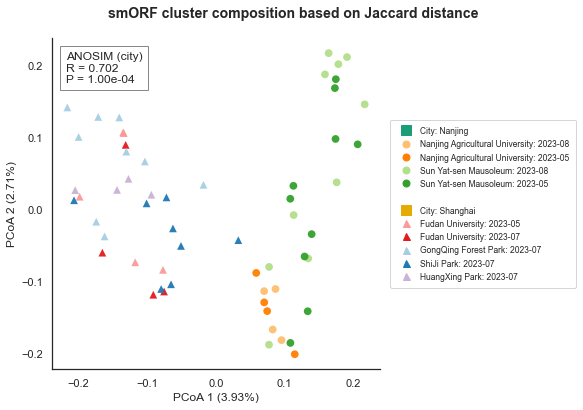

In [7]:
group_style = [
    ("Nanjing", "Nanjing Agricultural University", "2023-08", "#fdbf6f"),
    ("Nanjing", "Nanjing Agricultural University", "2023-05", "#ff7f00"),
    ("Nanjing", "Sun Yat-sen Mausoleum", "2023-08", "#b2df8a"),
    ("Nanjing", "Sun Yat-sen Mausoleum", "2023-05", "#33a02c"),
    ("Shanghai", "Fudan University", "2023-05", "#fb9a99"),
    ("Shanghai", "Fudan University", "2023-07", "#e31a1c"),
    ("Shanghai", "GongQing Forest Park", "2023-07", "#a6cee3"),
    ("Shanghai", "ShiJi Park", "2023-07", "#1f78b4"),
    ("Shanghai", "HuangXing Park", "2023-07", "#cab2d6"),
]
city_markers = {"Nanjing": "o", "Shanghai": "^"}
city_header_colors = {"Nanjing": "#1b9e77", "Shanghai": "#e6ab02"}

fig, ax = plt.subplots(figsize=(8.3, 5.8))
handles = []
current_city = None
for city, location, time, color in group_style:
    if city != current_city:
        if current_city is not None:
            handles.append(Line2D([], [], linestyle="none", label=" "))
        handles.append(
            Line2D(
                [], [], marker="s", linestyle="none", markersize=10,
                markerfacecolor=city_header_colors[city],
                markeredgecolor=city_header_colors[city],
                label=f"City: {city}",
            )
        )
        current_city = city
    subset = pcoa_scores.loc[
        pcoa_scores["City"].eq(city)
        & pcoa_scores["Location"].eq(location)
        & pcoa_scores["Time"].eq(time)
    ]
    marker = city_markers[city]
    ax.scatter(
        subset["PCoA1"], subset["PCoA2"],
        color=color, marker=marker, s=60, edgecolor="none", alpha=0.95,
    )
    handles.append(
        Line2D(
            [], [], marker=marker, linestyle="none", markersize=7,
            markerfacecolor=color, markeredgecolor=color,
            label=f"{location}: {time}",
        )
    )

city_result = anosim_results.loc[anosim_results["Comparison"].eq("City")].iloc[0]
p_text = f"{city_result.p_value:.2e}" if city_result.p_value < 0.001 else f"{city_result.p_value:.3f}"
ax.text(
    0.04, 0.96,
    f"ANOSIM (city)\nR = {city_result.R:.3f}\nP = {p_text}",
    transform=ax.transAxes, ha="left", va="top",
    bbox={"facecolor": "white", "edgecolor": "#888888", "boxstyle": "square,pad=0.45"},
)
ax.set_xlabel(f"PCoA 1 ({pcoa_explained[0] * 100:.2f}%)")
ax.set_ylabel(f"PCoA 2 ({pcoa_explained[1] * 100:.2f}%)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.legend(
    handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=True, fontsize=8.5, handletextpad=0.7, borderpad=0.8,
)
fig.suptitle("smORF cluster composition based on Jaccard distance",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()


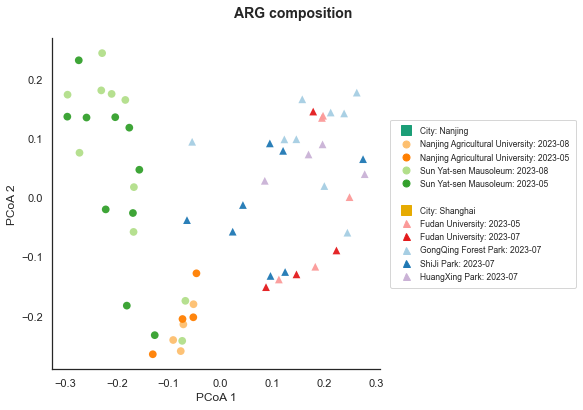

In [10]:
arg_scores = pd.read_csv("../pre-calculated_data/PCoA_ARGs.csv", index_col=0)
arg_scores["Sample_id"] = arg_scores["sample"].str.replace(r"^s(\d+)$", r"sample\1", regex=True)
arg_workbook = load_workbook("../pre-calculated_data/supp1_sample_metadata.xlsx",read_only=True, data_only=True)
arg_rows = list(arg_workbook["sample_metadata"].iter_rows(values_only=True))
arg_workbook.close()
arg_meta = pd.DataFrame(arg_rows[1:], columns=arg_rows[0])
def arg_month_label(value):
    for fmt in ("%m-%d-%Y", "%m-%Y", "%Y-%m-%d", "%Y-%m"):
        try:
            return pd.to_datetime(str(value).strip(), format=fmt).strftime("%Y-%m")
        except ValueError:
            pass
    raise ValueError(f"Unrecognized sample date: {value}")
arg_meta["Time"] = arg_meta["Date"].map(arg_month_label)
arg_scores = arg_scores.merge(
    arg_meta[["Sample_id", "City", "Location", "Time"]],
    on=["Sample_id", "City", "Location"], how="left", validate="one_to_one",
)

group_style = [
    ("Nanjing", "Nanjing Agricultural University", "2023-08", "#fdbf6f"),
    ("Nanjing", "Nanjing Agricultural University", "2023-05", "#ff7f00"),
    ("Nanjing", "Sun Yat-sen Mausoleum", "2023-08", "#b2df8a"),
    ("Nanjing", "Sun Yat-sen Mausoleum", "2023-05", "#33a02c"),
    ("Shanghai", "Fudan University", "2023-05", "#fb9a99"),
    ("Shanghai", "Fudan University", "2023-07", "#e31a1c"),
    ("Shanghai", "GongQing Forest Park", "2023-07", "#a6cee3"),
    ("Shanghai", "ShiJi Park", "2023-07", "#1f78b4"),
    ("Shanghai", "HuangXing Park", "2023-07", "#cab2d6"),
]
city_markers = {"Nanjing": "o", "Shanghai": "^"}
city_header_colors = {"Nanjing": "#1b9e77", "Shanghai": "#e6ab02"}

fig, ax = plt.subplots(figsize=(8.3, 5.8))
handles = []
current_city = None
for city, location, time, color in group_style:
    if city != current_city:
        if current_city is not None:
            handles.append(Line2D([], [], linestyle="none", label=" "))
        handles.append(
            Line2D(
                [], [], marker="s", linestyle="none", markersize=10,
                markerfacecolor=city_header_colors[city],
                markeredgecolor=city_header_colors[city],
                label=f"City: {city}",
            )
        )
        current_city = city
    subset = arg_scores.loc[
        arg_scores["City"].eq(city)
        & arg_scores["Location"].eq(location)
        & arg_scores["Time"].eq(time)
    ]
    marker = city_markers[city]
    ax.scatter(
        subset["PCo1"], subset["PCo2"],
        color=color, marker=marker, s=60, edgecolor="none", alpha=0.95,
    )
    handles.append(
        Line2D(
            [], [], marker=marker, linestyle="none", markersize=7,
            markerfacecolor=color, markeredgecolor=color,
            label=f"{location}: {time}",
        )
    )

ax.set_xlabel("PCoA 1")
ax.set_ylabel("PCoA 2")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.legend(
    handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=True, fontsize=8.5, handletextpad=0.7, borderpad=0.8,
)
fig.suptitle("ARG composition",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()
